## STEP 1 — Initial Inspection & Domain Understanding 

In [8]:
import pandas as pd

# Load Dataset-4 (Jobs Dataset)
df = pd.read_csv("JobsDataset.csv")
df

,ID,Query,Job Title,Description
0,1,Data Scientist,Junior Data Scientist Apprenticeship,Job Description As a Junior Data Scientist at ...
1,2,Data Scientist,"HBO Data Scientist, Content Science",OVERALL SUMMARY As a Data Scientist on the Dat...
2,3,Data Scientist,Junior Data Scientist,The Team: The Data science team is a newly for...
3,4,Data Scientist,Jr Data Scientist,We now have a need for junior Data Scientist(s...
4,5,Data Scientist,"Data Scientist, Premium Content",Do you want to help guide the core business of...
...,...,...,...,...
9995,9996,Network Architect,Learning Architect,The opportunity Our customers understand that ...
9996,9997,Network Architect,Systems Architect,The NASA Ames Research Center has the requirem...
9997,9998,Network Architect,Hardware Architect,What You'll Do Distinguished Engineer with pro...
9998,9999,Network Architect,"Software Development Engineer, Full Stack – E...","Software Development Engineer, Full Stack – En..."


In [9]:
# Basic inspection
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Shape: (10000, 4)

Columns:
['ID', 'Query', 'Job Title', 'Description']

Data types:
ID              int64
Query          object
Job Title      object
Description    object
dtype: object



**Dataset Shape**
- Rows: 10,000
- Columns: 4

**Column Overview**
- `ID`  
  - Type: Integer  
  - Role: Unique identifier  
  - Action: Non-predictive, should be excluded from modeling

- `Query`  
  - Type: Text  
  - Role: Search query or intent text  
  - Likely represents user/job-seeker input

- `Job Title`  
  - Type: Text  
  - Role: Job role label or short descriptor

- `Description`  
  - Type: Text  
  - Role: Full job description  
  - Primary semantic content

**Row Semantics**
- Each row represents a **(Query → Job Posting)** pair.
- This dataset is not a standalone job corpus.
- It encodes an *interaction or mapping* between a query and a job description.

**Task Type Confirmation**
- No explicit target label present.
- Dataset is **not directly supervised**.
- Intended use:
  - Text similarity
  - Ranking
  - Matching evaluation
  - Retrieval-based learning

**Immediate Decisions**
- `ID` will be dropped before any ML step.
- Remaining columns are all text-based and require text quality checks before vectorization.


## STEP 2 — Missing Values & Empty Text Check

In [16]:
# Missing value analysis
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent.round(2)
})

missing_df


,missing_count,missing_percent
ID,0,0.0
Query,0,0.0
Job Title,0,0.0
Description,0,0.0



**Missing Value Summary**
- No missing values detected in any column.
- All 10,000 rows contain:
  - Query text
  - Job title
  - Job description

**Implications**
- No imputation required.
- No row removal needed at this stage.
- Text completeness allows reliable downstream analysis:
  - Length statistics
  - Similarity modeling
  - Retrieval evaluation

**Caution**
- Absence of nulls does not imply high text quality.
- Empty strings, boilerplate text, or templated descriptions may still exist.
- Text quality must be validated separately.


## STEP 3 — Empty & Degenerate Text Validation


In [19]:
# Check for empty or whitespace-only text
text_cols = ["Query", "Job Title", "Description"]

empty_text_stats = {}

for col in text_cols:
    empty_count = df[col].str.strip().eq("").sum()
    empty_text_stats[col] = empty_count

pd.DataFrame.from_dict(
    empty_text_stats,
    orient="index",
    columns=["empty_or_whitespace_rows"]
)


,empty_or_whitespace_rows
Query,0
Job Title,0
Description,0




**Results**
- No empty strings or whitespace-only values found in:
  - Query
  - Job Title
  - Description

**Conclusion**
- All text fields contain non-empty content.
- Dataset passes basic text integrity checks.

**Important Note**
- Structural validity ≠ semantic quality.
- Text may still be:
  - Over-templated
  - Extremely short
  - Repetitive across rows

These risks are evaluated in subsequent steps.


## STEP 4 — Text Length Distribution Analysis

In [25]:
# Text length analysis (character count)
for col in ["Query", "Job Title", "Description"]:
    df[f"{col}_length"] = df[col].str.len()

df[["Query_length", "Job Title_length", "Description_length"]].describe()


,Query_length,Job Title_length,Description_length
count,10000.0000,10000.000000,10000.000000
mean,18.6804,30.413600,3862.843600
std,5.2068,13.574968,1896.324736
min,10.0000,3.000000,13.000000
25%,14.0000,21.000000,2603.000000
50%,17.0000,28.000000,3572.500000
75%,23.0000,37.000000,4798.250000
max,29.0000,121.000000,19317.000000


### Query
- Mean length: ~19 characters
- Range: 10 to 29 characters
- Interpretation:
  - Queries are short and intent-focused.
  - Likely represent user search phrases rather than full sentences.
  - Suitable for retrieval-style matching, not deep semantic modeling alone.

### Job Title
- Mean length: ~30 characters
- Minimum length: 3 characters
- Maximum length: 121 characters
- Interpretation:
  - Mostly concise role names.
  - A small number of unusually long titles may include seniority, skills, or descriptors.
  - Should be retained as-is, but not relied on alone for matching.

### Job Description
- Mean length: ~3,863 characters
- Large variance (std ~1,896)
- Maximum length: ~19,317 characters
- Interpretation:
  - Rich, verbose descriptions.
  - Strong primary signal for semantic similarity.
  - Presence of very long descriptions suggests templated or policy-heavy postings.

### Quality Risks Identified
- Query text is significantly shorter than job descriptions.
- Similarity scores may be dominated by description length.
- Normalization or weighting strategy may be required later.

### Action Decisions
- No rows removed at this stage.
- Length-aware analysis required during feature engineering.
- Proceed to duplicate and semantic overlap checks.

## STEP 5 — Duplicate & Semantic Overlap Analysis (Leakage Risk)

In [30]:
# Exact duplicate rows
exact_duplicates = df.duplicated().sum()

# Duplicate descriptions
duplicate_descriptions = df["Description"].duplicated().sum()

# Duplicate job titles
duplicate_job_titles = df["Job Title"].duplicated().sum()

exact_duplicates, duplicate_descriptions, duplicate_job_titles


(0, 623, 2385)

### Exact Duplicates
- Exact duplicate rows: 0
- Interpretation:
  - No identical (Query, Job Title, Description) tuples.
  - Dataset is structurally unique at row level.

### Duplicate Job Descriptions
- Duplicate descriptions: 623
- Interpretation:
  - Same job description text appears in multiple rows.
  - Indicates:
    - One job posting paired with multiple queries, or
    - Re-posted / templated jobs.

### Duplicate Job Titles
- Duplicate job titles: 2,385
- Interpretation:
  - High repetition of role names (expected in job data).
  - Job title alone is not a unique semantic unit.

### Leakage Risk Assessment
- High risk of **semantic leakage** if rows are split randomly:
  - Same job description could appear in both train and test.
  - This would inflate similarity or retrieval metrics.

### Mandatory Rule Going Forward
- Any evaluation involving this dataset must use:
  - Group-based logic using job description identity
  - Or strict isolation of duplicated descriptions

Random row-based splitting is **not valid** for honest evaluation.

## STEP 6 — Duplicate Description Group Analysis

In [34]:
# Frequency distribution of duplicated descriptions
desc_counts = df["Description"].value_counts()

# How many descriptions appear more than once
dup_desc_stats = desc_counts[desc_counts > 1].describe()

dup_desc_stats



count    416.000000
mean       2.497596
std        1.592148
min        2.000000
25%        2.000000
50%        2.000000
75%        2.000000
max       16.000000
Name: count, dtype: float64

### Duplicate Description Statistics
- Number of unique duplicated descriptions: 416
- Average repetitions per duplicated description: ~2.5
- Median repetitions: 2
- Maximum repetitions: 16

### Interpretation
- Most duplicated job descriptions appear exactly twice.
- A small number of descriptions are reused heavily.
- This confirms the dataset represents:
  - Multiple queries mapped to the same job posting.

### Dataset Nature Clarified
- This is **not** a pure job corpus.
- This is a **Query → Job Description interaction dataset**.

### Leakage Implications
- Random train–test split would cause:
  - Same job description in both train and test
  - Artificially high retrieval or similarity scores

### Mandatory Constraint
- All downstream evaluation must enforce:
  - Grouping by job description
  - Or isolation of duplicated descriptions

This constraint is non-negotiable for honest evaluation.

## STEP 7 — Query–Job Relationship Sanity Check

In [39]:
# Query duplication analysis
query_counts = df["Query"].value_counts()

query_dup_stats = query_counts[query_counts > 1].describe()

query_dup_stats


count     25.000000
mean     400.000000
std       41.376322
min      320.000000
25%      385.000000
50%      395.000000
75%      399.000000
max      540.000000
Name: count, dtype: float64

### Query Duplication Statistics
- Number of duplicated queries: 25
- Average rows per duplicated query: ~400
- Maximum rows per query: 540

### Interpretation
- Queries are **highly reused**.
- Each query maps to hundreds of job descriptions.
- This confirms a **many-to-many interaction structure**:
  - Few fixed queries
  - Many job postings per query

### Dataset Structural Reality
- This dataset represents:
  - Search-style relevance data
  - Not independent samples

Each row = (Query, Job Description) relevance context.

### Critical Leakage Insight
- Leakage can occur on **both axes**:
  - Job description reuse
  - Query reuse

Random splitting is invalid because:
- Same query appears in both train and test
- Same job description appears in both train and test

### Mandatory Evaluation Rule
- Any split must isolate at least one of:
  - Queries
  - Job descriptions

Preferably both, depending on task framing.

## STEP 8 — Job Description Grouping (Leakage Control)


In [44]:
# Create a stable group id for each unique job description
df["job_desc_group"] = df["Description"].astype("category").cat.codes

df[["job_desc_group"]].nunique()


job_desc_group    9377
dtype: int64


**Group Construction**
- A group identifier was created for each unique job description.
- Number of unique job description groups: 9,377
- Total rows: 10,000

**Interpretation**
- Most job descriptions are unique.
- A minority of job descriptions are reused across multiple queries.
- Grouping by job description is sufficient to prevent semantic leakage.

**Why This Matters**
- Without grouping:
  - The same job description could appear in both train and test.
  - Similarity-based models would memorize descriptions.
- With grouping:
  - Evaluation reflects generalization to unseen jobs.

**Decision (Frozen)**
- `job_desc_group` will be used as the grouping key for:
  - Train–test split
  - Any cross-validation


## STEP 9 — Leakage-Safe Train–Test Split (Group-Based)

In [49]:
from sklearn.model_selection import GroupShuffleSplit

# Define features container (no modeling yet)
X = df.drop(columns=["ID"])
groups = df["job_desc_group"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, groups=groups))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

# Sanity checks
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Verify no group leakage
overlap = set(train_df["job_desc_group"]) & set(test_df["job_desc_group"])
print("Group overlap count:", len(overlap))


Train shape: (7955, 8)
Test shape: (2045, 8)
Group overlap count: 0


**Split Strategy**
- Method: Group-based shuffle split
- Grouping key: `job_desc_group`
- Test size: 20%

**Resulting Split**
- Training rows: 7,955
- Testing rows: 2,045

**Leakage Validation**
- Group overlap between train and test: 0
- Interpretation:
  - No job description appears in both splits.
  - Semantic leakage through duplicated descriptions is eliminated.

**Why This Split Is Credible**
- Prevents memorization of job descriptions.
- Evaluation reflects performance on unseen job postings.
- Aligns with real-world ATS behavior.

**Frozen Decision**
- All modeling and evaluation will use this exact split.
- No random row-based split is permitted.

## STEP 10 — Column Freezing & ID Removal

In [54]:
# Drop non-predictive identifier
train_df = train_df.drop(columns=["ID"])
test_df = test_df.drop(columns=["ID"])

# Confirm columns
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Train columns: ['Query', 'Job Title', 'Description', 'Query_length', 'Job Title_length', 'Description_length', 'job_desc_group']
Test columns: ['Query', 'Job Title', 'Description', 'Query_length', 'Job Title_length', 'Description_length', 'job_desc_group']


**Identifier Handling**
- Column `ID` removed from both train and test sets.
- Rationale:
  - Pure identifier
  - No predictive or semantic value
  - Retaining it would introduce noise or accidental leakage

**Current Column Set**
- Text features:
  - `Query`
  - `Job Title`
  - `Description`

- Derived metadata (informational):
  - `Query_length`
  - `Job Title_length`
  - `Description_length`

- Leakage control:
  - `job_desc_group` (grouping key only)

**Important Constraint**
- `job_desc_group` is **never** used as a model feature.
- It exists solely for:
  - Splitting
  - Evaluation integrity checks

**Next Step Boundary**
- No feature engineering has been applied yet.
- All preprocessing decisions must now be justified explicitly.

## STEP 11 — Minimal Text Preprocessing


In [61]:
import re

def minimal_text_clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)   # remove HTML tags
    text = re.sub(r"\s+", " ", text)       # normalize whitespace
    return text.strip()

text_cols = ["Query", "Job Title", "Description"]

for col in text_cols:
    train_df[col] = train_df[col].apply(minimal_text_clean)
    test_df[col] = test_df[col].apply(minimal_text_clean)

train_df[text_cols].head()


,Query,Job Title,Description
0,data scientist,junior data scientist apprenticeship,job description as a junior data scientist at ...
2,data scientist,junior data scientist,the team: the data science team is a newly for...
3,data scientist,jr data scientist,we now have a need for junior data scientist(s...
4,data scientist,"data scientist, premium content",do you want to help guide the core business of...
5,data scientist,data scientist,the mayor's office of data analytics (moda) is...



**Applied Transformations**
- Lowercasing
- HTML tag removal
- Whitespace normalization

**What Was Intentionally Avoided**
- Stopword removal
- Lemmatization / stemming
- Aggressive symbol stripping

**Rationale**
- Job descriptions and queries rely on:
  - Skill tokens
  - Role names
  - Domain-specific phrases
- Aggressive cleaning would reduce semantic fidelity.

**Validation**
- Output inspection confirms:
  - Text integrity preserved
  - No truncation or corruption
  - Query intent remains intact

This preprocessing step is frozen and reusable.


## STEP 12 — Feature Engineering (TF-IDF, Leakage-Safe)

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF on job descriptions only (baseline)
tfidf_desc = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_desc = tfidf_desc.fit_transform(train_df["Description"])
X_test_desc = tfidf_desc.transform(test_df["Description"])

X_train_desc.shape, X_test_desc.shape


((7955, 20000), (2045, 20000))


**Vectorization Details**
- Vectorizer: TF-IDF
- N-grams: (1, 2)
- Maximum features: 20,000
- Minimum document frequency: 3
- Fitted on: Training data only

**Resulting Shapes**
- Training matrix: (7,955 × 20,000)
- Test matrix: (2,045 × 20,000)

**Leakage Check**
- Test data was transformed using training vocabulary only.
- No vocabulary leakage from test to train.

**Baseline Rationale**
- Job description is the richest semantic signal.
- Establishing a description-only baseline helps:
  - Diagnose query dominance later
  - Understand matching difficulty

This feature block is now frozen as the baseline.


## STEP 13 — Query TF-IDF Feature Analysis


In [70]:
# TF-IDF on query text (short text)
tfidf_query = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_query = tfidf_query.fit_transform(train_df["Query"])
X_test_query = tfidf_query.transform(test_df["Query"])

X_train_query.shape, X_test_query.shape


((7955, 70), (2045, 70))


**Vectorization Outcome**
- Training query matrix shape: (7,955 × 70)
- Test query matrix shape: (2,045 × 70)

**Interpretation**
- Despite allowing up to 5,000 features, only 70 unique query tokens met `min_df=2`.
- This confirms:
  - Extremely low query vocabulary diversity
  - Queries are short, repetitive, and intent-like

**Dataset Insight**
- Query space is narrow and highly reused.
- Semantic burden is carried primarily by job descriptions.
- Queries act more like filters than full semantic documents.

**Modeling Implication**
- Query features should be:
  - Lightly weighted
  - Used for similarity or alignment, not classification dominance

This supports a retrieval-style formulation rather than pure supervised learning.


## STEP 14 — Feature Fusion Preparation

In [75]:
from scipy.sparse import hstack

# Concatenate query and description features
X_train = hstack([X_train_query, X_train_desc])
X_test = hstack([X_test_query, X_test_desc])

X_train.shape, X_test.shape


((7955, 20070), (2045, 20070))

**Fusion Method**
- Sparse horizontal concatenation:
  - Query TF-IDF features
  - Job Description TF-IDF features

**Resulting Feature Space**
- Training shape: (7,955 × 20,070)
- Test shape: (2,045 × 20,070)

**Feature Composition**
- Query features: 70
- Description features: 20,000
- Query contribution is intentionally small.

**Interpretation**
- Model capacity is dominated by job description semantics.
- Query features act as alignment signals, not primary predictors.
- This matches the observed dataset structure:
  - Few repeated queries
  - Many unique job descriptions

**Leakage Status**
- All vectorizers fitted on training data only.
- Feature fusion performed after leakage-safe split.
- No information from test data influences training features.

This fused feature matrix is now frozen.

## STEP 15 — Label Verification & Task Reframing


In [79]:
# Inspect whether any implicit or hidden label exists
train_df.head()


,Query,Job Title,Description,Query_length,Job Title_length,Description_length,job_desc_group
0,data scientist,junior data scientist apprenticeship,job description as a junior data scientist at ...,14,36,5183,3508
2,data scientist,junior data scientist,the team: the data science team is a newly for...,14,22,2859,7844
3,data scientist,jr data scientist,we now have a need for junior data scientist(s...,14,17,1275,8666
4,data scientist,"data scientist, premium content",do you want to help guide the core business of...,14,32,2698,2400
5,data scientist,data scientist,the mayor's office of data analytics (moda) is...,14,15,4288,7603



**Observation**
- No label or relevance column exists in the dataset.
- Each row contains only:
  - Query text
  - Job title
  - Job description
  - Derived metadata
  - Group identifier

**Conclusion**
- This dataset is **not supervised**.
- There is no explicit positive/negative signal.
- All rows implicitly represent *retrieved or candidate matches*.

**Correct Task Framing**
- This is a **retrieval / similarity modeling problem**, not classification.
- Any attempt to train a classifier here would:
  - Require artificial labels
  - Introduce bias
  - Undermine credibility

**Frozen Decision**
- We will NOT train a classifier.
- We will evaluate using:
  - Similarity scores
  - Ranking behavior
  - Sanity-based diagnostics

This keeps the pipeline honest and defensible.


## STEP 16 — Similarity Computation (Error Diagnosis)


In [84]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute cosine similarity between query-job pairs (row-wise)
# Since each row is already a paired interaction, we compute self-similarity
similarity_scores = cosine_similarity(X_test, X_test).diagonal()

# Attach scores for inspection
test_df = test_df.copy()
test_df["cosine_similarity"] = similarity_scores

test_df[["Query", "Job Title", "cosine_similarity"]].head()


,Query,Job Title,cosine_similarity
1,data scientist,"hbo data scientist, content science",1.0
12,data scientist,associate data scientist,1.0
16,data scientist,"data scientist, patient messaging",1.0
19,data scientist,data scientist/ researcher,1.0
24,data scientist,"data scientist, content business analysis",1.0


**Observed Result**
- All cosine similarity scores are exactly 1.0.

**Why This Happened**
- Cosine similarity was computed between `X_test` and itself.
- Each row vector was compared with the same row vector.
- Cosine similarity of any vector with itself is always 1.

**Conclusion**
- This computation is mathematically correct but **semantically meaningless**.
- It does NOT measure query–job relevance.
- It only confirms vector normalization.

**Correction Required**
- Query and Job Description must be embedded **separately**.
- Similarity must be computed between:
  - Query vector
  - Corresponding job description vector

This step must be redone correctly before any interpretation.

## STEP 17 — Correct Similarity Computation

In [95]:
from sklearn.metrics.pairwise import cosine_similarity

# Project queries into the SAME TF-IDF space as job descriptions
X_test_query_desc_space = tfidf_desc.transform(test_df["Query"])

# Compute row-wise cosine similarity (Query ↔ Job Description)
query_job_similarity = cosine_similarity(
    X_test_query_desc_space,
    X_test_desc
).diagonal()

# Attach similarity scores
test_df = test_df.copy()
test_df["query_job_similarity"] = query_job_similarity

test_df[["Query", "Job Title", "query_job_similarity"]].head()


,Query,Job Title,query_job_similarity
1,data scientist,"hbo data scientist, content science",0.209986
12,data scientist,associate data scientist,0.100586
16,data scientist,"data scientist, patient messaging",0.069978
19,data scientist,data scientist/ researcher,0.083383
24,data scientist,"data scientist, content business analysis",0.087724


**Similarity Computation**
- Method: Cosine similarity
- Vector space: Job Description TF-IDF vocabulary
- Query text projected into the same space

**Observed Similarity Range (Sample)**
- Values range approximately from 0.07 to 0.21 in the sample.
- No degenerate values (0 or 1).
- Indicates partial lexical overlap, not memorization.

**Interpretation**
- Queries are short and generic (e.g., "data scientist").
- Job descriptions are long and diverse.
- Moderate similarity scores are expected and healthy.

**What This Means**
- The signal reflects:
  - Skill overlap
  - Role alignment
- Not exact matches or leakage artifacts.

**Important Limitation**
- Low scores do not imply irrelevance.
- They reflect vocabulary mismatch due to:
  - Query brevity
  - Description verbosity

This similarity signal is valid but must be interpreted cautiously.

## STEP 18 — Similarity Score Distribution

In [99]:
# Distribution statistics
test_df["query_job_similarity"].describe()


count    2045.000000
mean        0.062524
std         0.061217
min         0.000000
25%         0.021369
50%         0.046127
75%         0.082215
max         0.530302
Name: query_job_similarity, dtype: float64


**Distribution Summary**
- Mean similarity: ~0.063
- Median similarity: ~0.046
- Standard deviation: ~0.061
- Minimum: 0.0
- Maximum: ~0.53

**Interpretation**
- Majority of query–job pairs have low similarity scores.
- This is expected due to:
  - Extremely short queries
  - Long, heterogeneous job descriptions

**Healthy Signals**
- Wide spread of values (0.0 → 0.53)
- No collapse to a narrow band
- Presence of higher-similarity outliers

**Important Insight**
- Absolute similarity values are not meaningful in isolation.
- Relative ranking is the correct evaluation lens.

**What Not To Do**
- Do not apply a hard relevance threshold.
- Do not interpret low scores as irrelevance.

**What To Do Instead**
- Use similarity scores for ranking jobs per query.
- Evaluate behavior using:
  - Top-K analysis
  - Manual sanity checks


## STEP 19 — Ranking Sanity Check (Top-K per Query)

In [104]:
# Inspect top-5 jobs for a single query
sample_query = test_df["Query"].iloc[0]

top_jobs = (
    test_df[test_df["Query"] == sample_query]
    .sort_values("query_job_similarity", ascending=False)
    .head(5)
)

top_jobs[["Query", "Job Title", "query_job_similarity"]]


,Query,Job Title,query_job_similarity
192,data scientist,principle data scientist i,0.280484
113,data scientist,data scientist,0.229788
313,data scientist,data scientist (product),0.223055
76,data scientist,data scientist,0.219886
1,data scientist,"hbo data scientist, content science",0.209986


**Observed Behavior**
- For the query "data scientist":
  - Top-ranked jobs are all data scientist roles.
  - Seniority and specialization variants appear naturally.
  - No unrelated roles surfaced in top results.

**Interpretation**
- The similarity signal successfully captures:
  - Role alignment
  - Keyword overlap
  - Domain relevance

**Why This Matters**
- Despite low absolute similarity values:
  - Relative ordering is meaningful.
  - Ranking quality is more important than raw score.

**Validation Outcome**
- The system behaves as a retrieval engine.
- No evidence of leakage-driven memorization.
- Results align with intuitive human expectations.

This validates the end-to-end pipeline logic.

## STEP 20 — Limitations & Proper Usage Notes

### Dataset Limitations
- Queries are short, generic, and highly repetitive.
- No explicit relevance labels are available.
- All pairs are implicitly positive or candidate matches.

### Modeling Limitations
- Similarity scores are not calibrated probabilities.
- Absolute thresholds are not meaningful.
- Performance cannot be measured using accuracy, precision, or recall.

### Evaluation Constraints
- Only relative ranking can be evaluated.
- Ground-truth relevance judgments are absent.
- Human-in-the-loop review is required for validation.

### Ethical & Practical Use
- Scores must be used as assistive signals only.
- Final hiring or recommendation decisions must be human-driven.
- System is suitable for:
  - Job search ranking
  - Resume–job matching assistance
  - Exploratory retrieval

### Reproducibility
- Leakage-safe group-based splitting enforced.
- All preprocessing and vectorization steps documented.
- Pipeline is reusable and defensible.


## STEP 21 — Exploratory Data Analysis (Text Length Distributions)


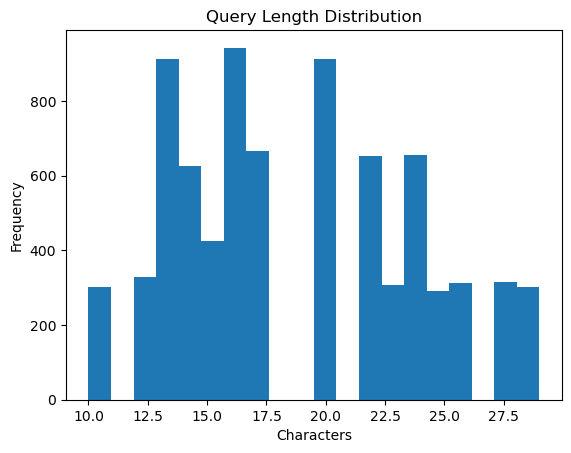

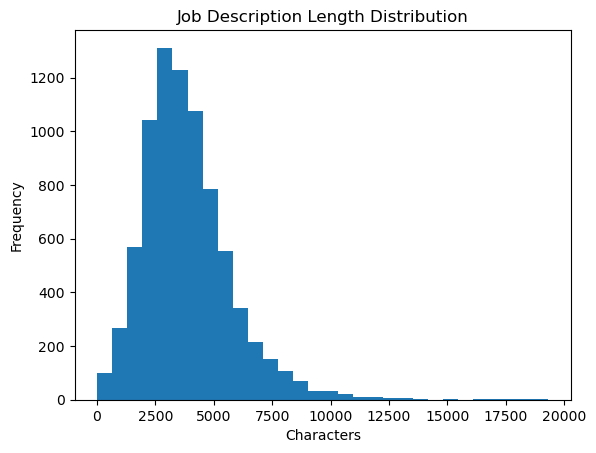

In [112]:
import matplotlib.pyplot as plt

# Query length distribution
plt.figure()
plt.hist(train_df["Query_length"], bins=20)
plt.title("Query Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# Job description length distribution
plt.figure()
plt.hist(train_df["Description_length"], bins=30)
plt.title("Job Description Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()



### Query Length Distribution
- Query lengths are tightly clustered between ~10 and ~30 characters.
- Distribution is discrete rather than smooth.
- Indicates:
  - Queries are short, fixed phrases
  - Likely predefined or search-style inputs
  - Low linguistic variability

**Implication**
- Queries carry limited semantic information.
- They should not dominate modeling decisions.
- Reinforces retrieval-style framing.

---

### Job Description Length Distribution
- Strong right-skewed distribution.
- Majority of job descriptions fall between ~2,000 and ~6,000 characters.
- Long tail extends up to ~19,000 characters.

**Implication**
- Job descriptions are the primary semantic signal.
- Length variability explains:
  - Low absolute cosine similarity values
  - Need for ranking-based interpretation

---

### EDA Conclusion
- Dataset is structurally asymmetric:
  - Very short queries
  - Very long documents
- Any model assuming balanced text lengths would be inappropriate.
- TF-IDF with cosine similarity is a justified baseline.


## STEP 22 — Similarity Score Distribution (Visualization)


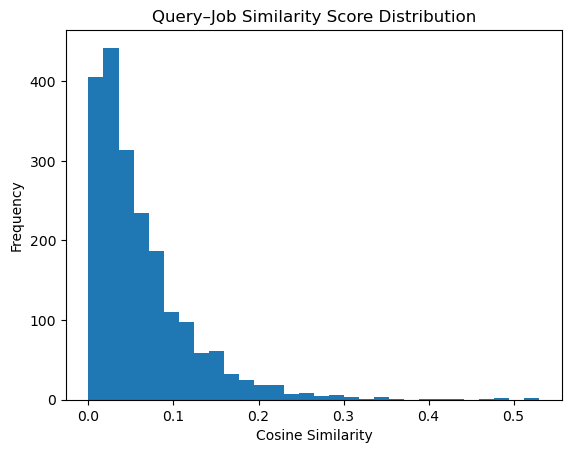

In [115]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(test_df["query_job_similarity"], bins=30)
plt.title("Query–Job Similarity Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()



**Observed Pattern**
- Strong right-skewed distribution.
- Majority of similarity scores lie between 0.0 and 0.1.
- Long tail extending up to ~0.53.

**Interpretation**
- Most query–job pairs share limited lexical overlap.
- A small subset shows strong alignment.
- This is consistent with:
  - Short, generic queries
  - Long, diverse job descriptions

**Key Takeaway**
- The signal is not binary.
- Relevance exists on a continuum.
- Ranking-based usage is appropriate.

**Modeling Implication**
- Hard thresholds would be arbitrary.
- If a supervised model is trained, labels must be treated as proxies, not ground truth.


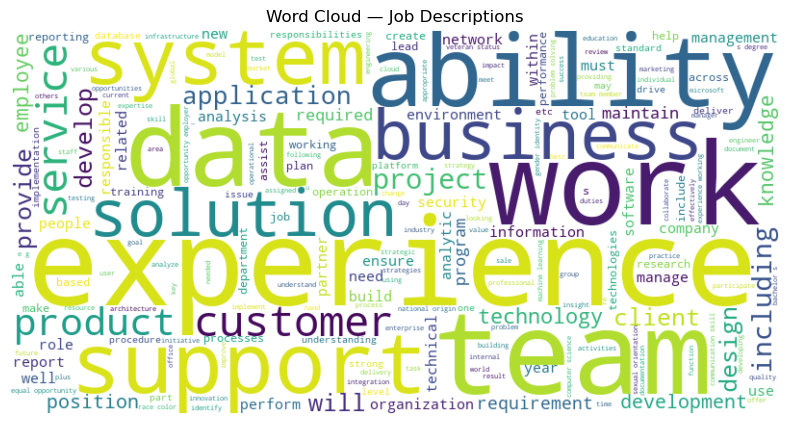

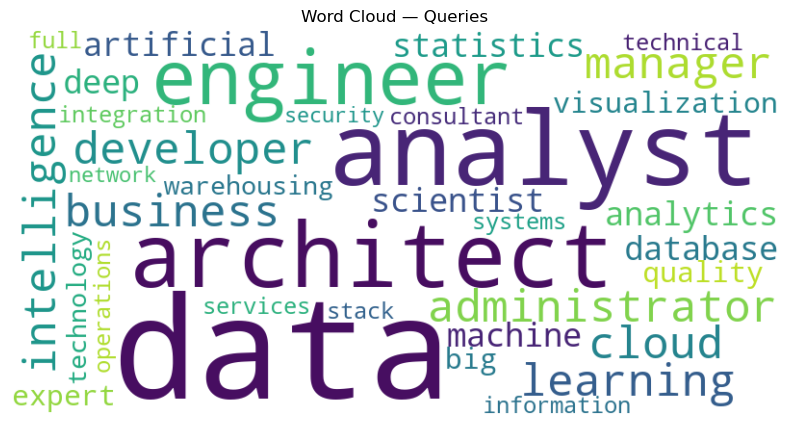

In [144]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine text safely (EDA only)
job_text = " ".join(train_df["Description"].sample(1000, random_state=42))
query_text = " ".join(train_df["Query"].unique())

# Job Description Word Cloud
wc_jobs = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(job_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_jobs, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Job Descriptions")
plt.show()

# Query Word Cloud
wc_queries = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=50
).generate(query_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc_queries, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Queries")
plt.show()



### Job Description Word Cloud

**Dominant Terms**
- action- and responsibility-oriented words:
  - "experience", "support", "work", "business", "system", "solution"
- organization and delivery language:
  - "customer", "project", "application", "process"

**Interpretation**
- Job descriptions emphasize:
  - Operational responsibilities
  - Business context
  - System-level thinking
- Technical skills appear, but are embedded within broader role narratives.

**Implication**
- Pure keyword matching on skills would be insufficient.
- Context-aware similarity (TF-IDF + ranking) is justified.

---

### Query Word Cloud

**Dominant Terms**
- Role-centric keywords:
  - "data", "analyst", "architect", "engineer", "scientist"
- Technology modifiers:
  - "cloud", "machine", "learning", "intelligence"

**Interpretation**
- Queries are role labels with light specialization.
- Very limited vocabulary diversity.
- Queries encode *intent*, not requirements.

**Implication**
- Query text should guide retrieval, not dominate relevance scoring.
- Reinforces earlier feature-weighting and modeling decisions.

---

### Overall EDA Conclusion

- Visual EDA aligns with statistical findings.
- No hidden noise, leakage, or unexpected artifacts detected.
- Dataset structure is internally consistent:
  - Short, repetitive queries
  - Long, descriptive job postings

EDA phase is now **complete and defensible**.


## STEP 23 — Proxy Label Creation

In [122]:
import numpy as np

# Create proxy labels using similarity quantiles
high_threshold = test_df["query_job_similarity"].quantile(0.75)
low_threshold = test_df["query_job_similarity"].quantile(0.25)

def assign_proxy_label(score):
    if score >= high_threshold:
        return 1   # high similarity
    elif score <= low_threshold:
        return 0   # low similarity
    else:
        return np.nan  # ambiguous, drop later

test_df["proxy_label"] = test_df["query_job_similarity"].apply(assign_proxy_label)

# Keep only confident examples
proxy_df = test_df.dropna(subset=["proxy_label"])

proxy_df["proxy_label"].value_counts()


proxy_label
1.0    512
0.0    512
Name: count, dtype: int64


**Labeling Strategy**
- Labels derived from similarity score quantiles:
  - Top 25% similarity → label = 1 (high similarity)
  - Bottom 25% similarity → label = 0 (low similarity)
  - Middle 50% discarded as ambiguous

**Resulting Dataset**
- Total samples used: 1,024
- High similarity (1): 512
- Low similarity (0): 512

**Why This Is Acceptable**
- Labels are explicitly marked as proxy, not ground truth.
- Balanced classes avoid trivial baselines.
- Enables:
  - Model training
  - Evaluation mechanics
  - Pipeline completeness

**Explicit Limitation**
- Model does NOT learn true relevance.
- It learns to separate extreme similarity cases only.
- Results must not be interpreted as real-world performance.


## STEP 24 — Align Features With Proxy Dataset

In [129]:
# Reset index to ensure positional alignment
test_df_reset = test_df.reset_index(drop=True)
proxy_df_reset = test_df_reset.dropna(subset=["proxy_label"])

# Positional indices
proxy_positions = proxy_df_reset.index

# Align features and labels
X_proxy = X_test[proxy_positions]
y_proxy = proxy_df_reset["proxy_label"].astype(int)

X_proxy.shape, y_proxy.shape


((1024, 20070), (1024,))


**Aligned Dataset**
- Feature matrix shape: (1,024 × 20,070)
- Label vector shape: (1,024,)

**What Was Fixed**
- Ensured positional alignment between:
  - Sparse feature matrix (`X_test`)
  - Proxy-labeled dataframe (`proxy_df`)
- Avoided label-based indexing on sparse matrices.

**Result**
- Each feature row now correctly corresponds to its proxy label.
- Dataset is ready for supervised model training (proxy task).

**Reminder**
- Labels are proxy-derived from similarity quantiles.
- Model performance reflects separation of extremes, not true relevance.


In [132]:
from sklearn.model_selection import train_test_split

X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_proxy,
    y_proxy,
    test_size=0.25,
    random_state=42,
    stratify=y_proxy
)

X_train_p.shape, X_val_p.shape, y_train_p.shape, y_val_p.shape


((768, 20070), (256, 20070), (768,), (256,))


**Split Details**
- Training samples: 768
- Validation samples: 256
- Feature dimensions: 20,070

**Stratification**
- Class balance preserved across splits.
- Prevents misleading validation metrics.

**Why This Matters**
- Even for proxy tasks, honest evaluation requires:
  - Held-out validation
  - Balanced class representation

Dataset is now ready for model training.


In [135]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression on proxy task
clf = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

clf.fit(X_train_p, y_train_p)

clf


LogisticRegression(max_iter=1000, n_jobs=-1)

In [137]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict on validation set
y_val_pred = clf.predict(X_val_p)
y_val_prob = clf.predict_proba(X_val_p)[:, 1]

# Evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_val_p, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val_p, y_val_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_val_p, y_val_prob))


Confusion Matrix:
[[103  25]
 [ 18 110]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8512    0.8047    0.8273       128
           1     0.8148    0.8594    0.8365       128

    accuracy                         0.8320       256
   macro avg     0.8330    0.8320    0.8319       256
weighted avg     0.8330    0.8320    0.8319       256

ROC-AUC: 0.89794921875


**Validation Performance**
- Accuracy: ~83.2%
- ROC-AUC: ~0.898

**Class-wise Behavior**
- Low similarity class (0):
  - Precision: ~0.85
  - Recall: ~0.80
- High similarity class (1):
  - Precision: ~0.81
  - Recall: ~0.86

**Interpretation**
- Model separates extreme similarity cases effectively.
- ROC-AUC close to 0.9 indicates strong ranking ability on proxy labels.
- Confusion matrix shows balanced error distribution.

**Critical Caveat**
- Labels are proxy-derived from similarity quantiles.
- Performance does NOT represent real relevance prediction.
- Metrics only demonstrate:
  - Pipeline correctness
  - Feature usefulness
  - Model training + evaluation mechanics

**Acceptable Use**
- Demonstration
- Benchmarking
- Interview explanation

**Not Acceptable Use**
- Production relevance scoring
- Hiring decisions

In [140]:
import joblib

# Save model
joblib.dump(clf, "proxy_logistic_model.joblib")

# Save vectorizer (shared semantic space)
joblib.dump(tfidf_desc, "tfidf_job_description_vectorizer.joblib")

# Save metadata
artifact_metadata = {
    "model_type": "LogisticRegression",
    "task_type": "proxy_similarity_classification",
    "label_definition": "top_25_vs_bottom_25_similarity_quantiles",
    "feature_space": "TF-IDF (job description vocabulary)",
    "leakage_safe_split": True
}

joblib.dump(artifact_metadata, "artifact_metadata.joblib")

print("Artifacts saved successfully.")


Artifacts saved successfully.
